In [1]:
# import the necessary libraries and functions
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(os.getcwd())

/Users/petrospolydorou/thesis/Documents/projectaria_sandbox/projectaria_tools/projects/AriaDigitalTwinDatasetTools/object_anticipation/adt


In [3]:
# define the filepath
file_path = os.path.join('data', 'results', 'llm_predictions_results.csv')

# prints
print(file_path)

# load the dataframe
df_d = pd.read_csv(file_path)

# show
df_d.head()

data/results/llm_predictions_results.csv


,sequence,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
0,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,15,0.188,0.188,0.500,0.375,0.5,3,13,10,3,0,6,16,15,6
1,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,30,0.188,0.188,0.500,0.375,0.5,3,13,10,3,0,6,16,15,6
2,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,45,0.059,0.062,0.167,0.312,0.2,1,15,11,4,1,6,16,15,5
3,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,60,0.133,0.143,0.333,0.357,0.4,2,12,9,3,1,6,14,13,5
4,Apartment_release_work_seq107_M1292,2,0.7,1.5,15,75,0.071,0.077,0.167,0.385,0.2,1,12,8,4,1,6,13,12,5


In [4]:
# the parameters that I have 
print("Below are the unique combinations of the parameters")

# prints 
print(f"The unique values of the dot counts are:",      df_d['sequence'].unique())
print(f"The unique values of the dot counts are:",      df_d['dot_counts'].unique())
print(f"The unique values of the distance counts are:", df_d['distance_counts'].unique())
print(f"The unique values of the dot values are:",      df_d['dot_value'].unique())
print(f"The unique values of the distance values are:", df_d['distance_value'].unique())
print(f"the unique values of the time are:",            df_d['time'].unique())

Below are the unique combinations of the parameters
The unique values of the dot counts are: ['Apartment_release_work_seq107_M1292'
 'Apartment_release_work_seq109_M1292'
 'Apartment_release_meal_seq131_M1292'
 'Apartment_release_meal_seq147_M1292'
 'Apartment_release_clean_seq133_M1292'
 'Apartment_release_clean_seq137_M1292'
 'Apartment_release_clean_seq142_M1292'
 'Apartment_release_clean_seq150_M1292']
The unique values of the dot counts are: [15 30 45 60 75 90]
The unique values of the distance counts are: [15 30 45 60 75 90]
The unique values of the dot values are: [0.7 0.8 0.9]
The unique values of the distance values are: [1.5 2.  2.5]
the unique values of the time are: [2]


In [5]:
# the parameters that I have 
print("Below are the unique outcomes")
print('_')
print(f"The unique values of model accuarcy are:")
print(df_d['model_overall_accuracy'].unique())
print('_')
print(f"The unique values of precision are:", df_d['precision'].unique())
print('_')
print(f"The unique values of recall are:", df_d['recall'].unique())
print('_')
print(f"The unique values of llm activation sensitivity are:", df_d['llm_activation_sensitivity'].unique())
print('_')
print(f"the unique values of llm interaction accuracy are:", df_d['llm_interaction_accuracy'].unique())
print('_')

Below are the unique outcomes
_
The unique values of model accuarcy are:
[0.188 0.059 0.133 0.071 0.083 0.2   0.062 0.143 0.077 0.154 0.1   0.167
 0.091 0.182 0.    0.15  0.158 0.125 0.067 0.222 0.095 0.105 0.048 0.05
 0.118 0.231 0.111 0.214 0.211 0.176 0.053 0.056 0.136 0.13  0.174 0.25
 0.286 0.273 0.042 0.043 0.045 0.087 0.037 0.08  0.04  0.115 0.069 0.074
 0.12  0.107 0.034 0.038 0.208 0.19  0.103 0.16  0.148 0.129 0.097 0.138
 0.094 0.185 0.031 0.065 0.172 0.192 0.292 0.261 0.217 0.207 0.24  0.227
 0.241 0.179 0.033 0.061 0.03  0.036 0.121 0.238 0.368 0.278 0.389 0.235
 0.318 0.3   0.316 0.333 0.269 0.294 0.28  0.353 0.35  0.412 0.304 0.267
 0.263]
_
The unique values of precision are: [0.188 0.062 0.143 0.077 0.091 0.2   0.067 0.167 0.083 0.111 0.1   0.
 0.15  0.158 0.059 0.125 0.133 0.071 0.222 0.154 0.095 0.105 0.048 0.05
 0.118 0.231 0.182 0.214 0.333 0.211 0.176 0.3   0.286 0.267 0.25  0.5
 0.056 0.273 0.13  0.042 0.136 0.043 0.053 0.045 0.087 0.308 0.444 0.375
 0.385 0.364 

In [6]:
# Sequence - dataframes
sequence_dataframes_dict = {seq: df_d[df_d['sequence'] == seq].drop(df_d.columns[0], axis=1) for seq in df_d['sequence'].unique()}
sequence_dataframes_list = [df_d[df_d['sequence'] == seq].drop(df_d.columns[0], axis=1).reset_index() for seq in df_d['sequence'].unique()]
df_d_clean_150 = sequence_dataframes_dict['Apartment_release_clean_seq150_M1292']
df_d_clean_142 = sequence_dataframes_dict['Apartment_release_clean_seq142_M1292']
df_d_clean_137 = sequence_dataframes_dict['Apartment_release_clean_seq137_M1292']
df_d_clean_133 = sequence_dataframes_dict['Apartment_release_clean_seq133_M1292']
df_d_meal_147 = sequence_dataframes_dict['Apartment_release_meal_seq147_M1292']
df_d_meal_131 = sequence_dataframes_dict['Apartment_release_meal_seq131_M1292']
df_d_work_109 = sequence_dataframes_dict['Apartment_release_work_seq109_M1292']
df_d_work_107 = sequence_dataframes_dict['Apartment_release_work_seq107_M1292']


In [7]:
df_d_clean_137.tail()

,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
1939,2,0.9,2.5,90,30,0.050,0.083,0.067,0.583,0.143,1,11,5,6,8,13,12,11,7
1940,2,0.9,2.5,90,45,0.050,0.083,0.067,0.583,0.143,1,11,5,6,8,13,12,11,7
1941,2,0.9,2.5,90,60,0.050,0.083,0.067,0.583,0.143,1,11,5,6,8,13,12,11,7
1942,2,0.9,2.5,90,75,0.050,0.083,0.067,0.583,0.143,1,11,5,6,8,13,12,11,7
1943,2,0.9,2.5,90,90,0.053,0.091,0.067,0.636,0.143,1,10,4,6,8,13,11,10,7


# Line Plots of Performance Metrics vs. Parameter Values

Model Overall Accuracy vs. dot_counts

*Purpose*: Show how changing the dot_counts parameter affects the model_overall_accuracy.

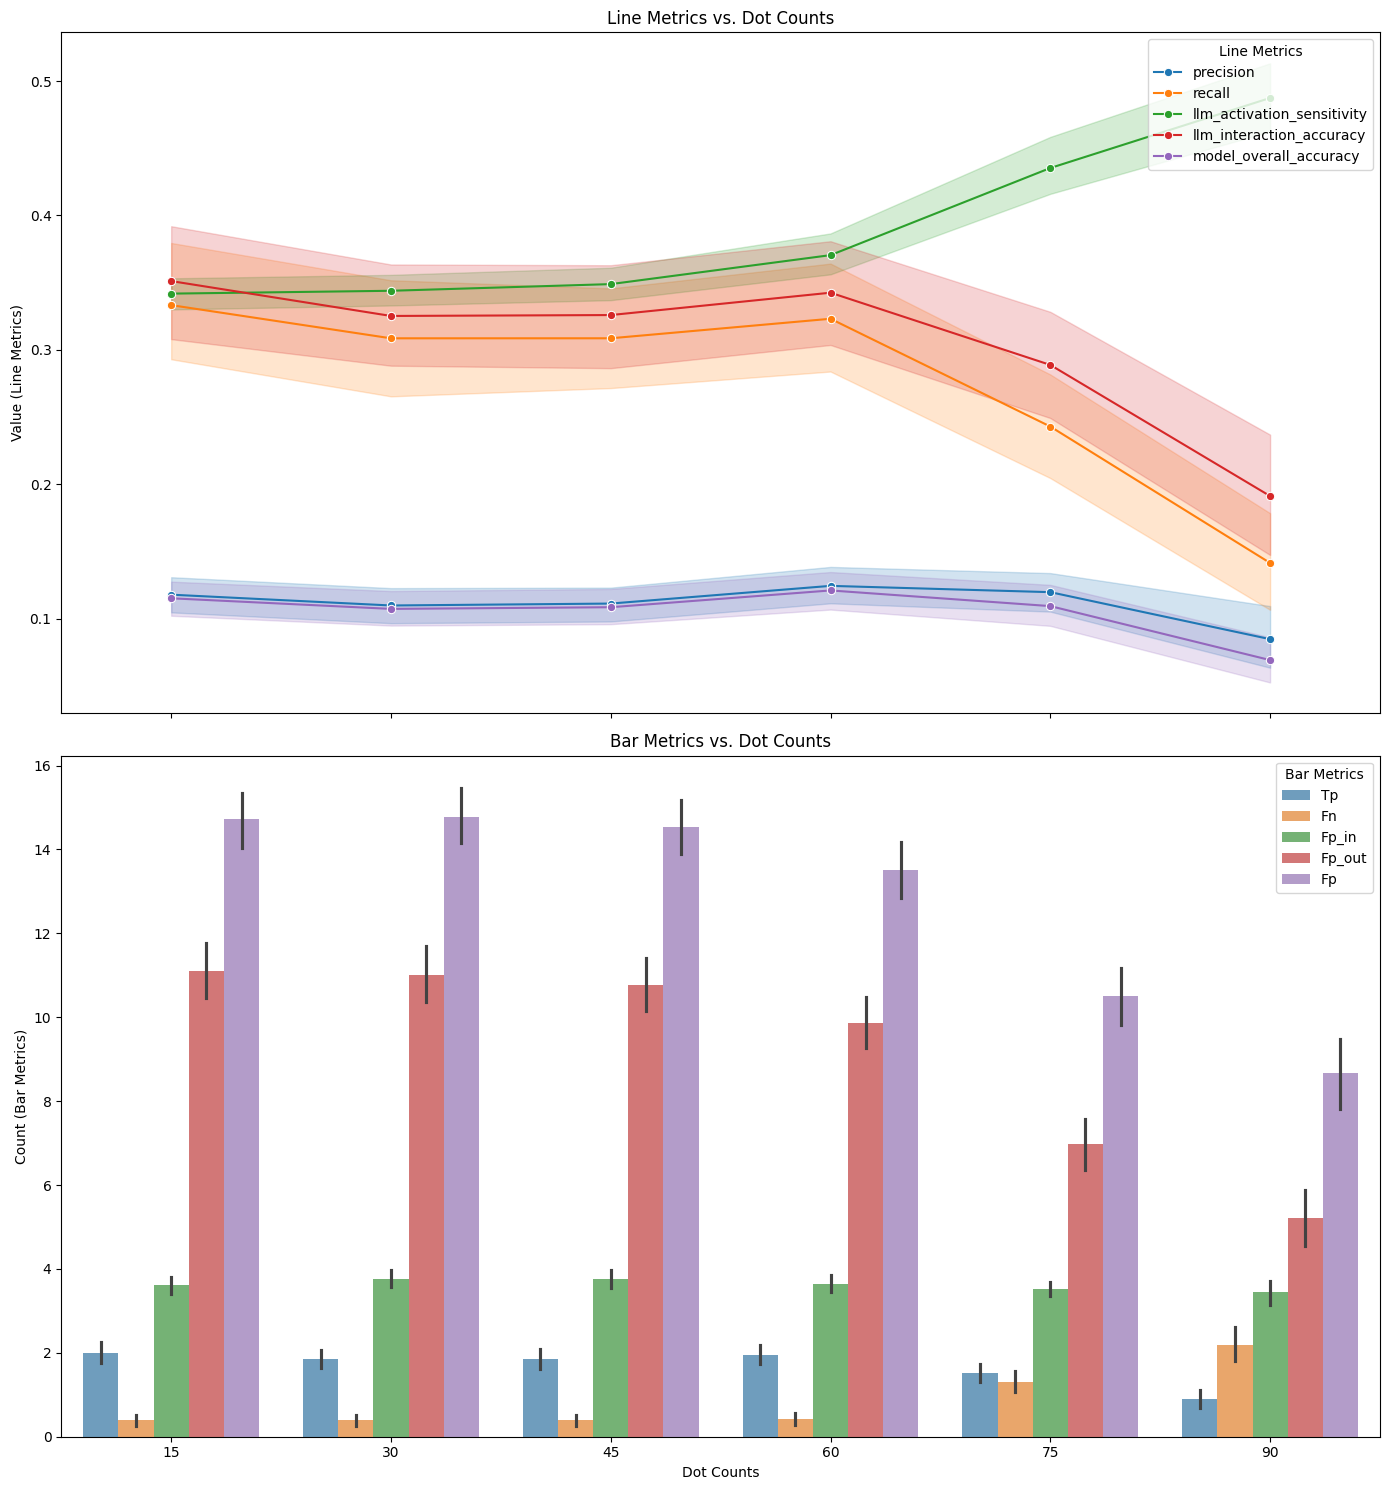

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics to plot
bar_metrics = ['Tp', 'Fn', 'Fp_in', 'Fp_out', 'Fp']
line_metrics = ['precision', 'recall', 'llm_activation_sensitivity', 'llm_interaction_accuracy', 'model_overall_accuracy']

# Melt the DataFrame for seaborn
metrics = df_d_work_107.melt(
    id_vars=['dot_counts'],
    value_vars=bar_metrics + line_metrics,
    var_name='Metric',
    value_name='Value'
)

# Convert 'distance_counts' to a categorical type
metrics['dot_counts'] = metrics['dot_counts'].astype(str)

# Create the figure and axes for subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 15), sharex=True)  # Increased width from 12 to 16

# Plot line metrics on the first (top) subplot
sns.lineplot(
    data=metrics[metrics['Metric'].isin(line_metrics)],
    x='dot_counts',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[0]
)
ax[0].set_ylabel('Value (Line Metrics)')
ax[0].set_title('Line Metrics vs. Dot Counts')

# Place the legend inside the plot area
ax[0].legend(title='Line Metrics', loc='upper right')  # Adjust 'loc' as needed

# Plot bar metrics on the second (bottom) subplot
sns.barplot(
    data=metrics[metrics['Metric'].isin(bar_metrics)],
    x='dot_counts',
    y='Value',
    hue='Metric',
    dodge=True,
    ax=ax[1],
    alpha=0.7
)
ax[1].set_ylabel('Count (Bar Metrics)')
ax[1].set_xlabel('Dot Counts')
ax[1].set_title('Bar Metrics vs. Dot Counts')

# Place the legend inside the plot area
ax[1].legend(title='Bar Metrics', loc='upper right')  # Adjust 'loc' as needed

# Adjust the overall title and layout
# plt.suptitle('Metrics vs. Dot Counts', y=0.95)
plt.tight_layout()  # Removed 'rect' parameter

# Save and show the plot
plt.savefig('work_107_subplots_tp_fp_fn_vs_dot_counts')
plt.show()

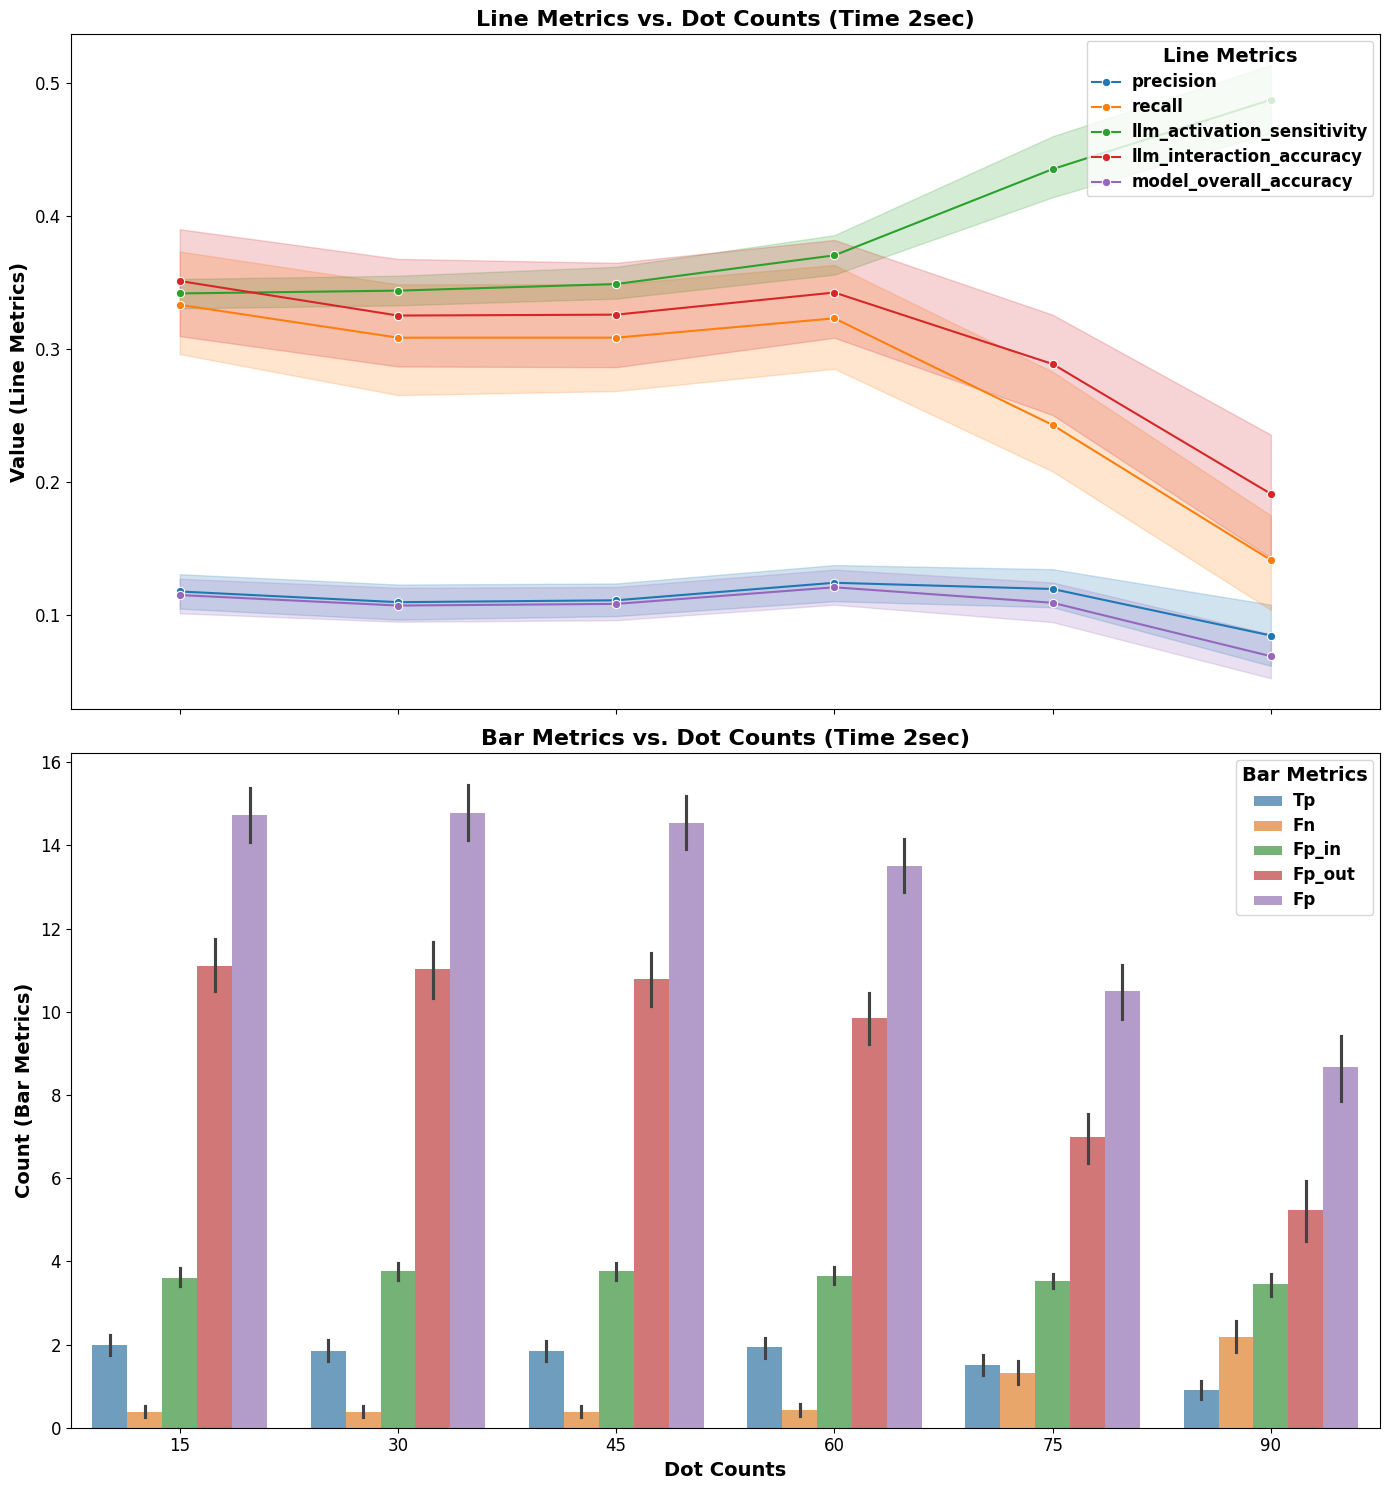

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics to plot
bar_metrics = ['Tp', 'Fn', 'Fp_in', 'Fp_out', 'Fp']
line_metrics = ['precision', 'recall', 'llm_activation_sensitivity', 'llm_interaction_accuracy', 'model_overall_accuracy']

# Melt the DataFrame for seaborn
metrics = df_d_work_107.melt(
    id_vars=['dot_counts'],
    value_vars=bar_metrics + line_metrics,
    var_name='Metric',
    value_name='Value'
)

# Convert 'distance_counts' to a categorical type
metrics['dot_counts'] = metrics['dot_counts'].astype(str)

# Create the figure and axes for subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 15), sharex=True)  # Increased width from 12 to 16

# Plot line metrics on the first (top) subplot
sns.lineplot(
    data=metrics[metrics['Metric'].isin(line_metrics)],
    x='dot_counts',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[0]
)

# Set bold font for titles and labels with larger font size
ax[0].set_ylabel('Value (Line Metrics)', fontweight='bold', fontsize=14)
ax[0].set_title('Line Metrics vs. Dot Counts (Time 2sec)', fontweight='bold', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=12)

# Customize legend to have bold text and larger font size
legend_line = ax[0].legend(title='Line Metrics', loc='upper right')
plt.setp(legend_line.get_texts(), fontweight='bold', fontsize=12)  # Set legend text to bold and larger
plt.setp(legend_line.get_title(), fontweight='bold', fontsize=14)  # Set legend title to bold and larger

# Plot bar metrics on the second (bottom) subplot
sns.barplot(
    data=metrics[metrics['Metric'].isin(bar_metrics)],
    x='dot_counts',
    y='Value',
    hue='Metric',
    dodge=True,
    ax=ax[1],
    alpha=0.7
)

# Set bold font for titles and labels with larger font size
ax[1].set_ylabel('Count (Bar Metrics)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Dot Counts', fontweight='bold', fontsize=14)
ax[1].set_title('Bar Metrics vs. Dot Counts (Time 2sec)', fontweight='bold', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=12)

# Customize legend to have bold text and larger font size
legend_bar = ax[1].legend(title='Bar Metrics', loc='upper right')
plt.setp(legend_bar.get_texts(), fontweight='bold', fontsize=12)  # Set legend text to bold and larger
plt.setp(legend_bar.get_title(), fontweight='bold', fontsize=14)  # Set legend title to bold and larger

# Adjust layout
plt.tight_layout()
plt.savefig('df_d_work_107_subplots_tp_fp_fn_vs_dot_counts_bold')
plt.show()


In [ ]:
# df_d_clean_150 
# df_d_clean_142 
# df_d_clean_137
# df_d_clean_133
# df_d_meal_147
# df_d_meal_131
# df_d_work_109 
# df_d_work_107

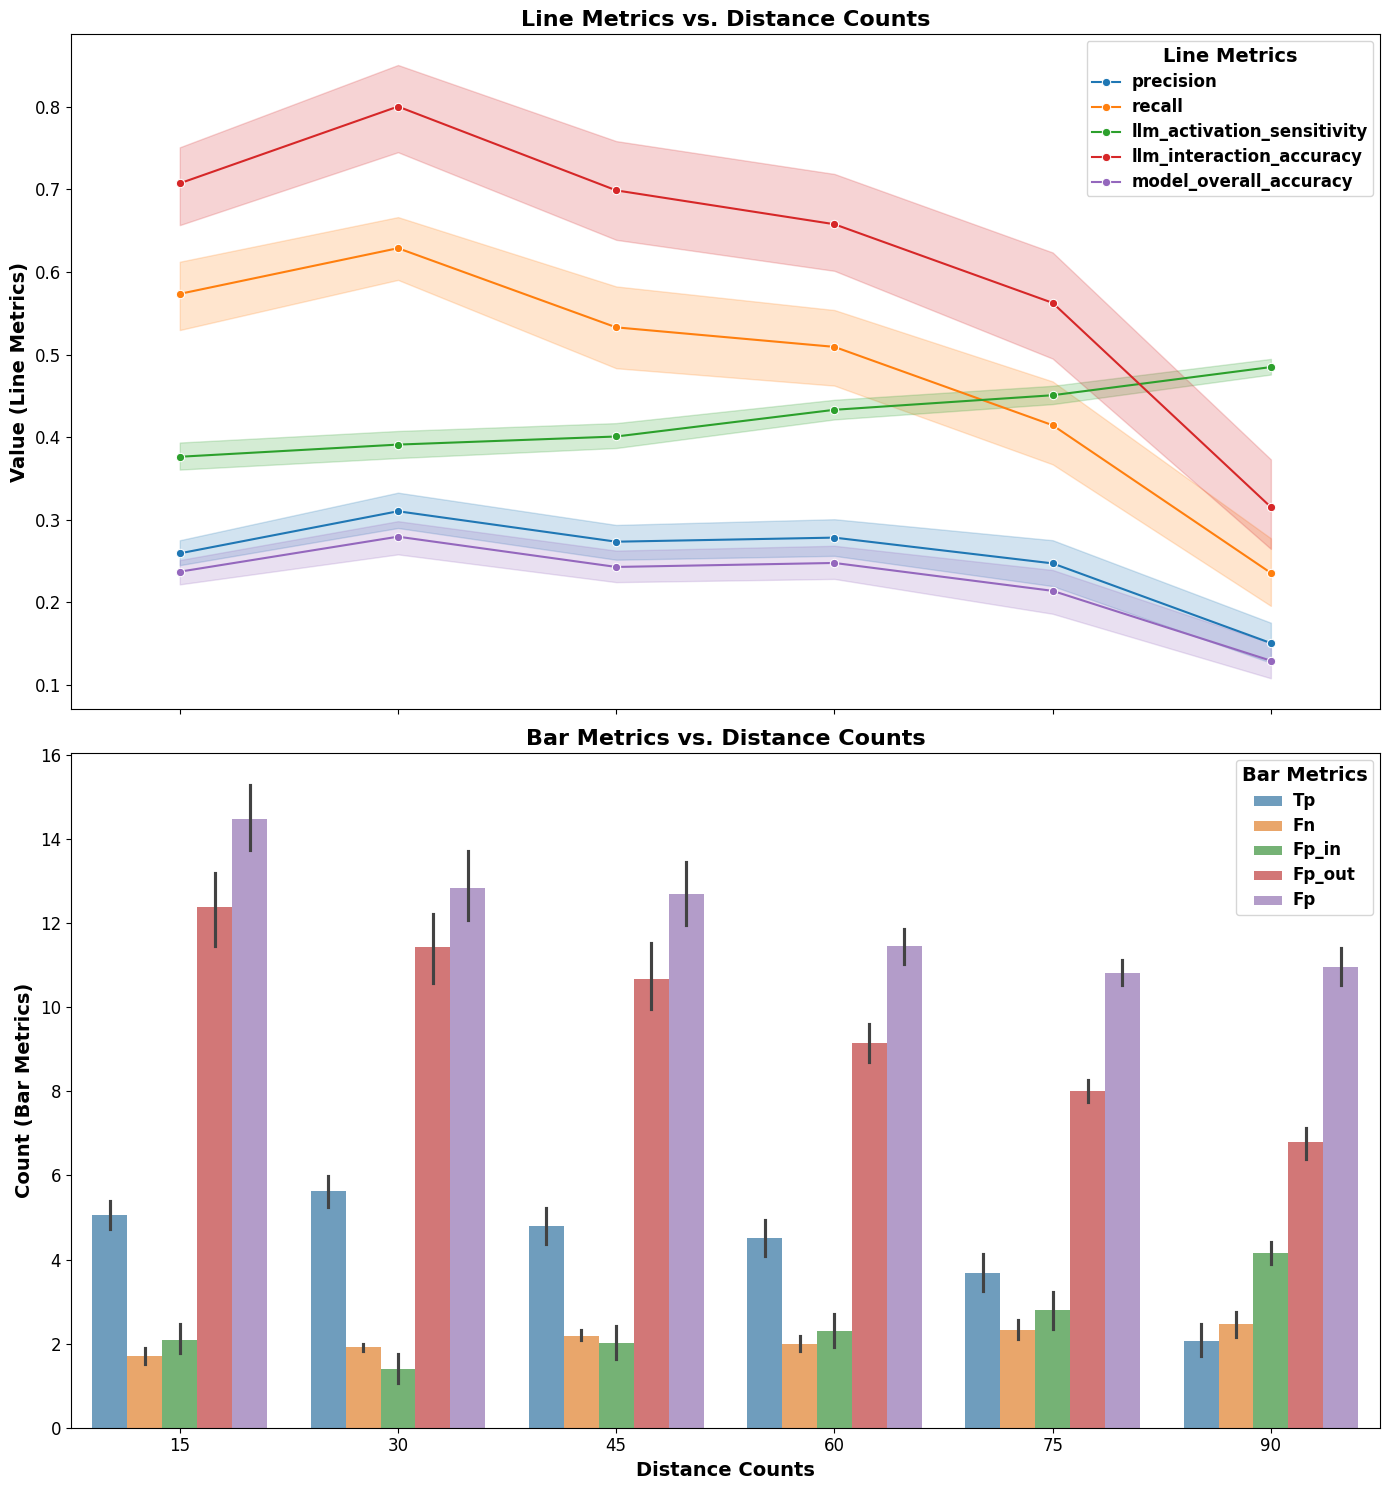

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics to plot
bar_metrics = ['Tp', 'Fn', 'Fp_in', 'Fp_out', 'Fp']
line_metrics = ['precision', 'recall', 'llm_activation_sensitivity', 'llm_interaction_accuracy', 'model_overall_accuracy']

# Melt the DataFrame for seaborn
metrics = df_d_clean_150.melt(
    id_vars=['distance_counts'],
    value_vars=bar_metrics + line_metrics,
    var_name='Metric',
    value_name='Value'
)

# Convert 'distance_counts' to a categorical type
metrics['distance_counts'] = metrics['distance_counts'].astype(str)

# Create the figure and axes for subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 15), sharex=True)  # Increased width from 12 to 16

# Plot line metrics on the first (top) subplot
sns.lineplot(
    data=metrics[metrics['Metric'].isin(line_metrics)],
    x='distance_counts',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[0]
)

# Set bold font for titles and labels with larger font size
ax[0].set_ylabel('Value (Line Metrics)', fontweight='bold', fontsize=14)
ax[0].set_title('Line Metrics vs. Distance Counts', fontweight='bold', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=12)

# Customize legend to have bold text and larger font size
legend_line = ax[0].legend(title='Line Metrics', loc='upper right')
plt.setp(legend_line.get_texts(), fontweight='bold', fontsize=12)  # Set legend text to bold and larger
plt.setp(legend_line.get_title(), fontweight='bold', fontsize=14)  # Set legend title to bold and larger

# Plot bar metrics on the second (bottom) subplot
sns.barplot(
    data=metrics[metrics['Metric'].isin(bar_metrics)],
    x='distance_counts',
    y='Value',
    hue='Metric',
    dodge=True,
    ax=ax[1],
    alpha=0.7
)

# Set bold font for titles and labels with larger font size
ax[1].set_ylabel('Count (Bar Metrics)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Distance Counts', fontweight='bold', fontsize=14)
ax[1].set_title('Bar Metrics vs. Distance Counts', fontweight='bold', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=12)

# Customize legend to have bold text and larger font size
legend_bar = ax[1].legend(title='Bar Metrics', loc='upper right')
plt.setp(legend_bar.get_texts(), fontweight='bold', fontsize=12)  # Set legend text to bold and larger
plt.setp(legend_bar.get_title(), fontweight='bold', fontsize=14)  # Set legend title to bold and larger

# Adjust layout
plt.tight_layout()
plt.savefig('df_d_clean_150_subplots_tp_fp_fn_vs_distance_counts_bold')
plt.show()


In [22]:
# define the filepath
file_path_150_values_times15 = os.path.join('data', 'results', 'llm_predictions_results_clean_150_values_times15.csv')

# prints
print(file_path_150_values_times15)

# load the dataframe
df_d_150_15 = pd.read_csv(file_path_150_values_times15)
df_d_150_15 = df_d_150_15[df_d_150_15['distance_counts'] == 30]
df_d_150_15 = df_d_150_15[df_d_150_15['distance_value'] != 1]
# show
df_d_150_15.head()

data/results/llm_predictions_results_clean_150_values_times15.csv


,sequence,time,dot_value,distance_value,dot_counts,distance_counts,model_overall_accuracy,precision,recall,llm_activation_sensitivity,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
2,Apartment_release_clean_seq150_M1292,1.5,0.6,1.5,60,30,0.389,0.438,0.778,0.438,1.000,7,9,9,0,2,8,16,15,7
3,Apartment_release_clean_seq150_M1292,1.5,0.6,1.5,75,30,0.333,0.375,0.667,0.438,0.857,6,10,9,1,2,8,16,15,7
4,Apartment_release_clean_seq150_M1292,1.5,0.6,2.0,60,30,0.316,0.353,0.667,0.412,0.857,6,11,10,1,2,8,17,16,7
5,Apartment_release_clean_seq150_M1292,1.5,0.6,2.0,75,30,0.263,0.294,0.556,0.412,0.714,5,12,10,2,2,8,17,16,7
6,Apartment_release_clean_seq150_M1292,1.5,0.6,2.5,60,30,0.238,0.263,0.556,0.368,0.714,5,14,12,2,2,8,19,18,7


In [23]:
print(f"The unique values of the dot counts {df_d_150_15['dot_counts'].unique()}")
print('_')
print(f"The unique values of the distance counts {df_d_150_15['distance_counts'].unique()}")
print('_')
print(f"The unique values of the time {df_d_150_15['time'].unique()}")
print('_')
print(f"The unique values of the dot values are:", df_d_150_15['dot_value'].unique())
print('_')
print(f"The unique values of the distance values are:", df_d_150_15['distance_value'].unique())

The unique values of the dot counts [60 75]
_
The unique values of the distance counts [30]
_
The unique values of the time [1.5]
_
The unique values of the dot values are: [0.6  0.7  0.8  0.9  0.95]
_
The unique values of the distance values are: [1.5 2.  2.5 3.  3.5]


In [24]:
# the parameters that I have 
print("Below are the unique outcomes")
print('_')
print(f"The unique values of model accuarcy are:", df_d_150_15['model_overall_accuracy'].unique())
print('_')
print(f"The unique values of precision are:", df_d_150_15['precision'].unique())
print('_')
print(f"The unique values of recall are:", df_d_150_15['recall'].unique())
print('_')
print(f"The unique values of llm activation sensitivity are:", df_d_150_15['llm_activation_sensitivity'].unique())
print('_')
print(f"the unique values of llm interaction accuracy are:", df_d_150_15['llm_interaction_accuracy'].unique())
print('_')
print(f"the unique values of true postiives are:", df_d_150_15['Tp'].unique())
print('_')
print(f"the unique values of false postives are:", df_d_150_15['Fp'].unique())

Below are the unique outcomes
_
The unique values of model accuarcy are: [0.389 0.333 0.316 0.263 0.238 0.286 0.278 0.368 0.294 0.3   0.35  0.412
 0.353 0.438 0.429 0.267]
_
The unique values of precision are: [0.438 0.375 0.353 0.294 0.263 0.316 0.368 0.312 0.412 0.333 0.389 0.467
 0.4   0.5   0.385 0.308]
_
The unique values of recall are: [0.778 0.667 0.556 0.444]
_
The unique values of llm activation sensitivity are: [0.438 0.412 0.368 0.467 0.389 0.5   0.583 0.538]
_
the unique values of llm interaction accuracy are: [1.    0.857 0.714 0.571]
_
the unique values of true postiives are: [7 6 5 4]
_
the unique values of false postives are: [ 9 10 11 12 14 13  8  7  6]


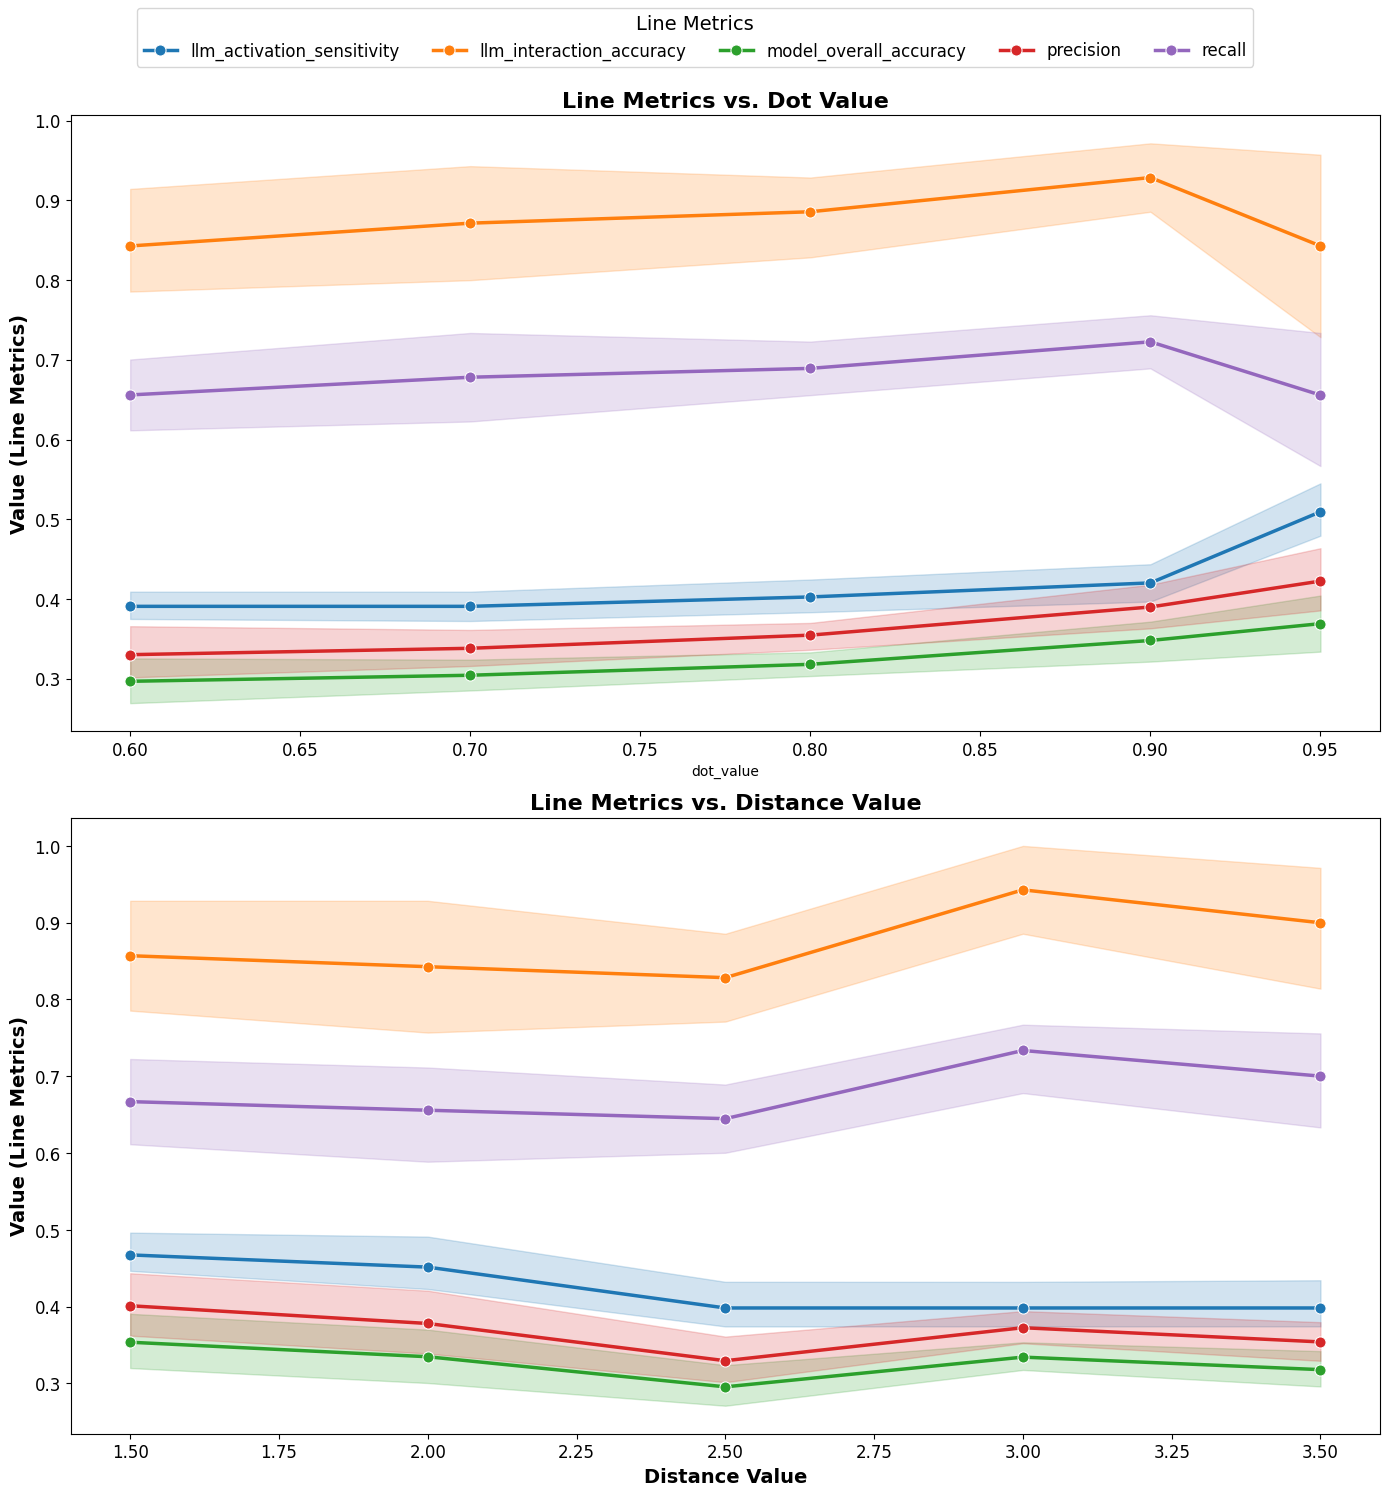

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Metrics to plot
bar_metrics = ['Tp', 'Fn', 'Fp_in', 'Fp_out', 'Fp']
line_metrics = [
    'precision',
    'recall',
    'llm_activation_sensitivity',
    'llm_interaction_accuracy',
    'model_overall_accuracy'
]

# Melt the DataFrame for seaborn, including both 'dot_value' and 'distance_value' in id_vars
metrics = df_d_150_15.melt(
    id_vars=['dot_value', 'distance_value'],
    value_vars=line_metrics,
    var_name='Metric',
    value_name='Value'
)

# Ensure 'dot_value' and 'distance_value' are numeric
metrics['dot_value'] = pd.to_numeric(metrics['dot_value'], errors='coerce')
metrics['distance_value'] = pd.to_numeric(metrics['distance_value'], errors='coerce')

# Drop rows with NaN in 'dot_value' or 'distance_value' if any
metrics.dropna(subset=['dot_value', 'distance_value'], inplace=True)

# Sort the data by Metric and the respective x-axis for consistent plotting
metrics.sort_values(['Metric', 'dot_value'], inplace=True)

# Create the figure and axes for subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 15), sharex=False)  # sharex=False since different x-axes

# ----------------------------
# First Subplot: Line Metrics vs. Dot Value
# ----------------------------
sns.lineplot(
    data=metrics,
    x='dot_value',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[0],
    linewidth=2.5,
    markersize=8
    # ci=95 # ci="sd"
)

# Set bold font for titles and labels with larger font size
ax[0].set_ylabel('Value (Line Metrics)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Dot Value', fontweight='bold', fontsize=14)
ax[0].set_title('Line Metrics vs. Dot Value', fontweight='bold', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=12)

# ----------------------------
# Second Subplot: Line Metrics vs. Distance Value
# ----------------------------
sns.lineplot(
    data=metrics,
    x='distance_value',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[1],
    linewidth=2.5,
    markersize=8,
    # ci="sd"
)

# Set bold font for titles and labels with larger font size
ax[1].set_ylabel('Value (Line Metrics)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Distance Value', fontweight='bold', fontsize=14)
ax[1].set_title('Line Metrics vs. Distance Value', fontweight='bold', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=12)

# ----------------------------
# Legend Customization
# ----------------------------
# To avoid duplicate legends, we can create a single legend for both plots
# First, get handles and labels from the first subplot
handles, labels = ax[0].get_legend_handles_labels()

# Remove legends from both subplots
ax[0].get_legend().remove()
ax[1].get_legend().remove()

# Create a single legend below both subplots
fig.legend(handles, labels, title='Line Metrics', fontsize=12, title_fontsize=14, loc='upper center', ncol=5)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the rect to leave space for the legend at the top

# Save the figure
plt.savefig('subplots_line_metrics_dot_distance.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [42]:
# define the filepath
file_path_150_reactivation = os.path.join('data', 'results', 'llm_predictions_results_clean_150_reactivation.csv')

# prints
print(file_path_150_reactivation)

# load the dataframe
df_d_150_ra = pd.read_csv(file_path_150_reactivation)
df_d_150_ra = df_d_150_ra[df_d_150_ra['distance_counts'] == 30]
df_d_150_ra = df_d_150_ra[df_d_150_ra['distance_value'] != 1]

data/results/llm_predictions_results_clean_150_reactivation.csv


In [43]:
df_d_150_ra.head()

,sequence,time,dot_value,distance_value,dot_counts,distance_counts,minimum_time,maximum_time,movement,model_overall_accuracy,...,llm_interaction_accuracy,Tp,Fp,Fp_out,Fp_in,Fn,Total_ground_truths,Total_llm_predictions,Total_llm_activations,Total_correspondances
0,Apartment_release_clean_seq150_M1292,1.5,0.9,1.5,60,30,1.0,3.0,1.0,0.318,...,1.0,7,13,13,0,2,8,20,19,7
1,Apartment_release_clean_seq150_M1292,1.5,0.9,1.5,60,30,1.0,3.0,2.0,0.318,...,1.0,7,13,13,0,2,8,20,19,7
2,Apartment_release_clean_seq150_M1292,1.5,0.9,1.5,60,30,1.0,3.0,3.0,0.318,...,1.0,7,13,13,0,2,8,20,19,7
3,Apartment_release_clean_seq150_M1292,1.5,0.9,1.5,60,30,1.0,5.0,1.0,0.318,...,1.0,7,13,13,0,2,8,20,19,7
4,Apartment_release_clean_seq150_M1292,1.5,0.9,1.5,60,30,1.0,5.0,2.0,0.318,...,1.0,7,13,13,0,2,8,20,19,7


In [44]:
print(f"The unique values of the dot counts {df_d_150_ra['dot_counts'].unique()}")
print('_')
print(f"The unique values of the distance counts {df_d_150_ra['distance_counts'].unique()}")
print('_')
print(f"The unique values of the time {df_d_150_ra['time'].unique()}")
print('_')
print(f"The unique values of the dot values are:", df_d_150_ra['dot_value'].unique())
print('_')
print(f"The unique values of the distance values are:", df_d_150_ra['distance_value'].unique())
print('_')
print(f"The unique values of the minimum time are:", df_d_150_ra['minimum_time'].unique())
print('_')
print(f"The unique values of the maximum time are:", df_d_150_ra['maximum_time'].unique())
print('_')
print(f"The unique values of the movement are:", df_d_150_ra['movement'].unique())

The unique values of the dot counts [60 75]
_
The unique values of the distance counts [30]
_
The unique values of the time [1.5]
_
The unique values of the dot values are: [0.9  0.95]
_
The unique values of the distance values are: [1.5 3. ]
_
The unique values of the minimum time are: [1. 2. 3.]
_
The unique values of the maximum time are: [3. 5. 6.]
_
The unique values of the movement are: [1. 2. 3.]


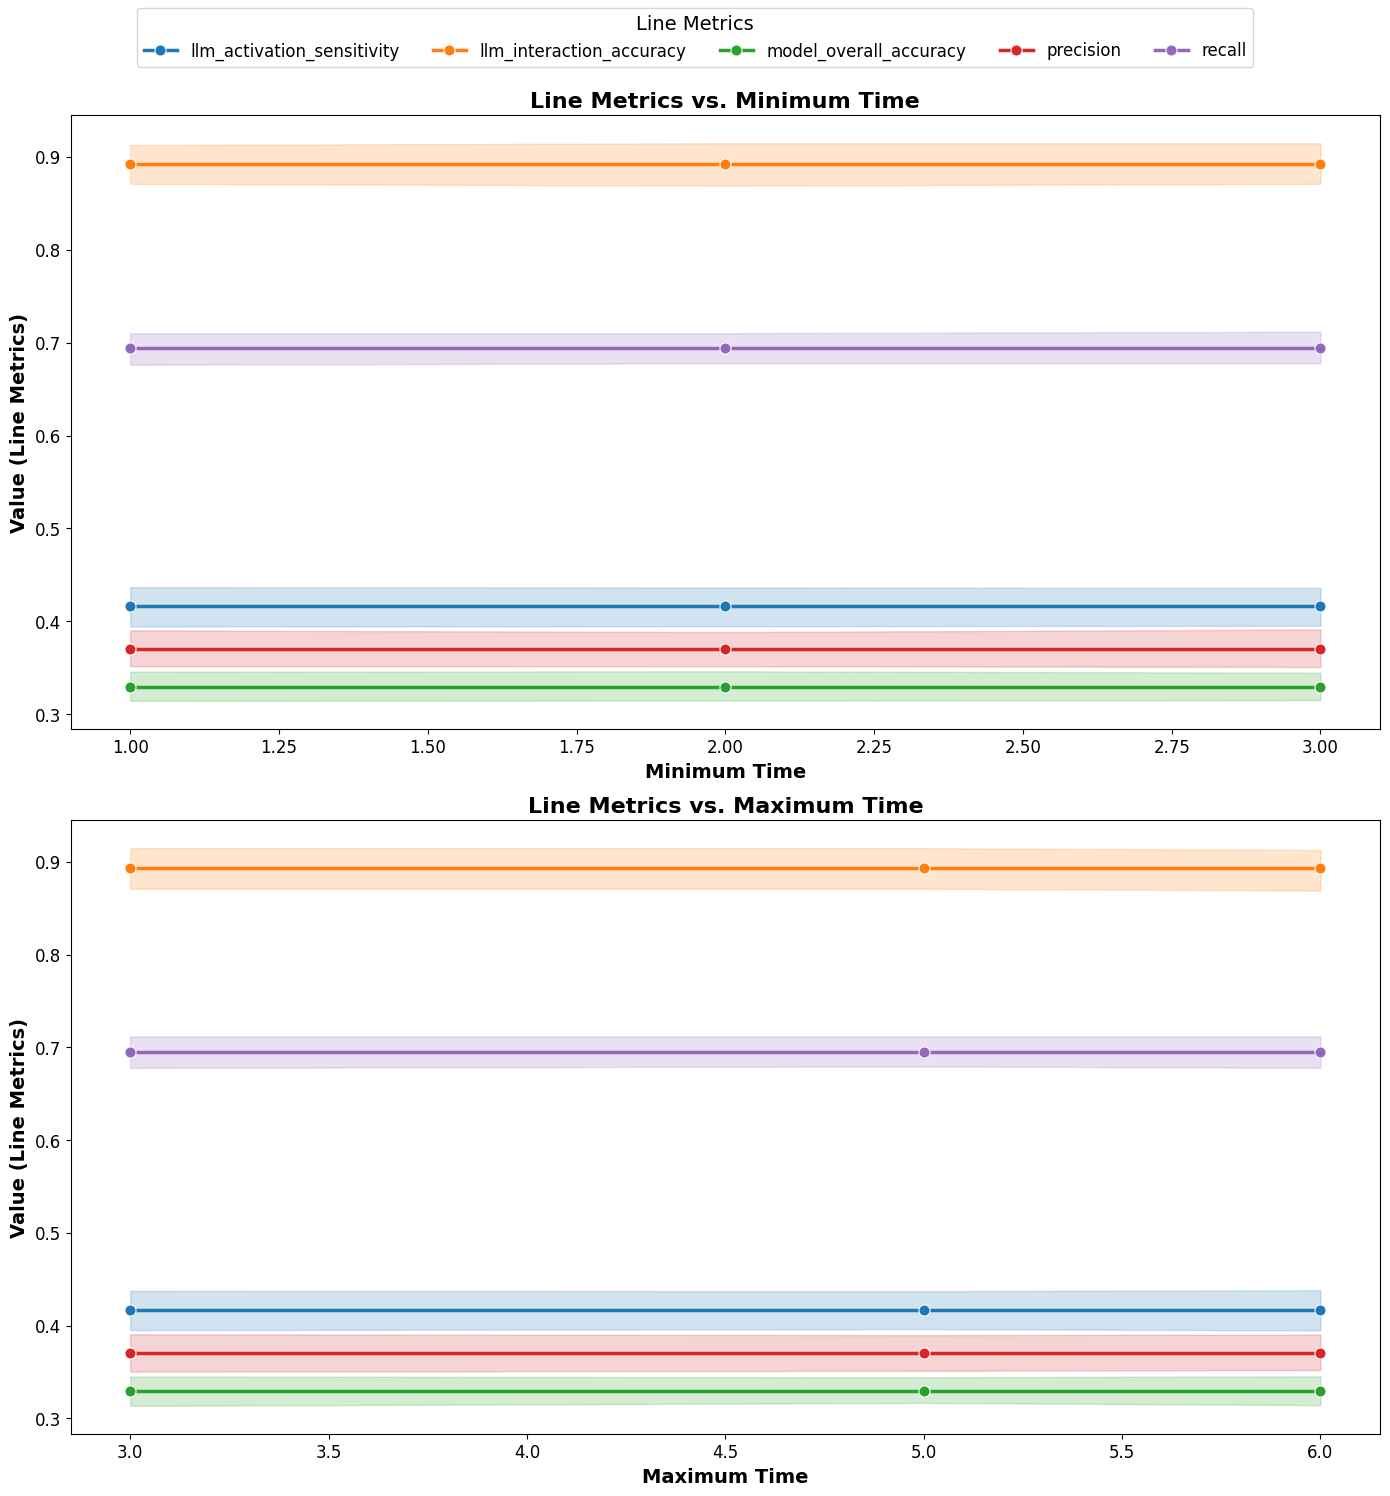

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Metrics to plot
line_metrics = [
    'precision',
    'recall',
    'llm_activation_sensitivity',
    'llm_interaction_accuracy',
    'model_overall_accuracy'
]

# Melt the DataFrame for seaborn, including 'minimum_time' and 'maximum_time' in id_vars
metrics = df_d_150_ra.melt(
    id_vars=['minimum_time', 'maximum_time'],
    value_vars=line_metrics,
    var_name='Metric',
    value_name='Value'
)

# Ensure 'minimum_time' and 'maximum_time' are numeric
metrics['minimum_time'] = pd.to_numeric(metrics['minimum_time'], errors='coerce')
metrics['maximum_time'] = pd.to_numeric(metrics['maximum_time'], errors='coerce')

# Drop rows with NaN in 'minimum_time' or 'maximum_time' if any
metrics.dropna(subset=['minimum_time', 'maximum_time'], inplace=True)

# Sort the data by Metric and the respective x-axis for consistent plotting
metrics.sort_values(['Metric', 'minimum_time'], inplace=True)

# Create the figure and axes for subplots
fig, ax = plt.subplots(2, 1, figsize=(14, 15), sharex=False)  # sharex=False since different x-axes

# ----------------------------
# First Subplot: Line Metrics vs. Minimum Time
# ----------------------------
sns.lineplot(
    data=metrics,
    x='minimum_time',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[0],
    linewidth=2.5,
    markersize=8
    # ci=95 # ci="sd"
)

# Set bold font for titles and labels with larger font size
ax[0].set_ylabel('Value (Line Metrics)', fontweight='bold', fontsize=14)
ax[0].set_xlabel('Minimum Time', fontweight='bold', fontsize=14)
ax[0].set_title('Line Metrics vs. Minimum Time', fontweight='bold', fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=12)

# ----------------------------
# Second Subplot: Line Metrics vs. Maximum Time
# ----------------------------
sns.lineplot(
    data=metrics,
    x='maximum_time',
    y='Value',
    hue='Metric',
    marker='o',
    ax=ax[1],
    linewidth=2.5,
    markersize=8,
    # ci="sd"
)

# Set bold font for titles and labels with larger font size
ax[1].set_ylabel('Value (Line Metrics)', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Maximum Time', fontweight='bold', fontsize=14)
ax[1].set_title('Line Metrics vs. Maximum Time', fontweight='bold', fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=12)

# ----------------------------
# Legend Customization
# ----------------------------
# To avoid duplicate legends, we can create a single legend for both plots
# First, get handles and labels from the first subplot
handles, labels = ax[0].get_legend_handles_labels()

# Remove legends from both subplots
ax[0].get_legend().remove()
ax[1].get_legend().remove()

# Create a single legend below both subplots
fig.legend(handles, labels, title='Line Metrics', fontsize=12, title_fontsize=14, loc='upper center', ncol=5)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the rect to leave space for the legend at the top

# Save the figure
plt.savefig('subplots_line_metrics_min_max_time.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


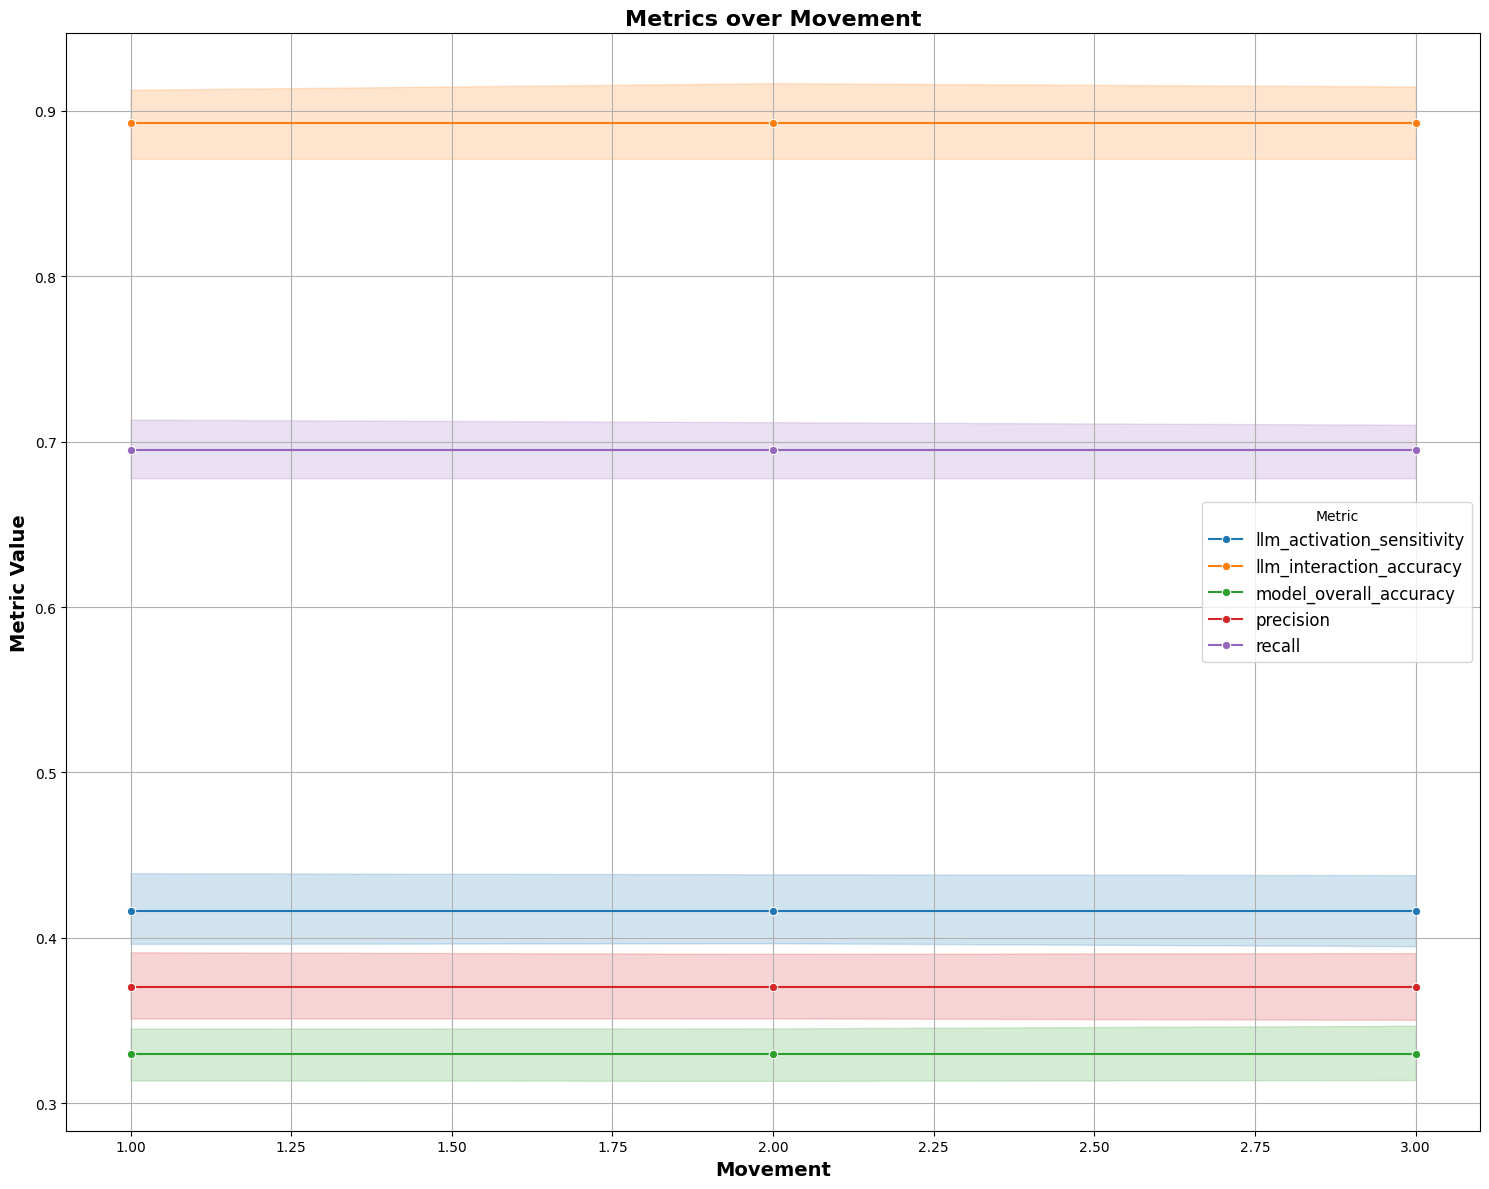

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Metrics to plot
line_metrics = [
    'precision',
    'recall',
    'llm_activation_sensitivity',
    'llm_interaction_accuracy',
    'model_overall_accuracy'
]

# Melt the DataFrame for seaborn, including 'minimum_time' and 'maximum_time' in id_vars
metrics = df_d_150_ra.melt(
    id_vars=['movement'],
    value_vars=line_metrics,
    var_name='Metric',
    value_name='Value'
)

# Ensure 'minimum_time' and 'maximum_time' are numeric
metrics['movement'] = pd.to_numeric(metrics['movement'], errors='coerce')

# Drop rows with NaN in 'minimum_time' or 'maximum_time' if any
metrics.dropna(subset=['movement'], inplace=True)

# Sort the data by Metric and the respective x-axis for consistent plotting
metrics.sort_values(['Metric', 'movement'], inplace=True)

# ----------------------------
# First Subplot: Line Metrics vs. Minimum Time
# ----------------------------

# Plot using seaborn
plt.figure(figsize=(15, 12))
sns.lineplot(data=metrics, x='movement', y='Value', hue='Metric', marker='o')

# Customize the plot
plt.title('Metrics over Movement', fontsize=16, fontweight='bold')
plt.xlabel('Movement', fontsize=14, fontweight='bold')
plt.ylabel('Metric Value', fontsize=14, fontweight='bold')
plt.legend(title='Metric', fontsize=12, loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"movement_performance_metrics.png")
plt.show()


In [22]:
df_d_150_15_15 = df_d_150_15[df_d_150_15['dot_value'] == 0.9]
df_d_150_15_15.head()
df_d_150_15_15['dot_value'].unique()

array([0.9])